In [27]:
from google.colab import drive
drive.mount('/content/drive')

# 1️⃣ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2️⃣ Set paths
zip_path = '/content/drive/MyDrive/Emotion-Project.zip'
extract_path = '/content/Emotion-Project'

# 3️⃣ Unzip
!unzip -q "{zip_path}" -d "{extract_path}"
print("✅ Unzipped successfully at:", extract_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Unzipped successfully at: /content/Emotion-Project


In [28]:
# Cell 1: Imports & Paths
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.mixture import GaussianMixture
from google.colab import files

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [29]:
# === COLAB PATHS ===
FER_TRAIN = '/content/Emotion-Project/Emotion-Project/facial_detection_dataset/train'
FER_TEST  = '/content/Emotion-Project/Emotion-Project/facial_detection_dataset/test'
MUSIC_INFO = '/content/Emotion-Project/Emotion-Project/movie_recommendation_dataset/Music Info.csv'
USER_HISTORY = '/content/Emotion-Project/Emotion-Project/movie_recommendation_dataset/User Listening History.csv'
MP3_FOLDER = '/content/Emotion-Project/Emotion-Project/movie_recommendation_dataset/MP3-Example'  # optional

print('Paths set:')
print('FER_TRAIN =', FER_TRAIN)
print('FER_TEST  =', FER_TEST)
print('MUSIC_INFO =', MUSIC_INFO)
print('USER_HISTORY =', USER_HISTORY)
print('MP3_FOLDER =', MP3_FOLDER)

Paths set:
FER_TRAIN = /content/Emotion-Project/Emotion-Project/facial_detection_dataset/train
FER_TEST  = /content/Emotion-Project/Emotion-Project/facial_detection_dataset/test
MUSIC_INFO = /content/Emotion-Project/Emotion-Project/movie_recommendation_dataset/Music Info.csv
USER_HISTORY = /content/Emotion-Project/Emotion-Project/movie_recommendation_dataset/User Listening History.csv
MP3_FOLDER = /content/Emotion-Project/Emotion-Project/movie_recommendation_dataset/MP3-Example


In [30]:
import os

# Check train folder
print("Train folder contents:", os.listdir(FER_TRAIN)[:7])  # first 5 folders

# Check test folder
print("Test folder contents:", os.listdir(FER_TEST)[:7])

# Check CSV files
print("Music Info exists?", os.path.exists(MUSIC_INFO))
print("User History exists?", os.path.exists(USER_HISTORY))


Train folder contents: ['surprise', 'fear', 'neutral', 'angry', 'happy', 'sad', 'disgust']
Test folder contents: ['surprise', 'fear', 'neutral', 'angry', 'happy', 'sad', 'disgust']
Music Info exists? False
User History exists? False


In [ ]:
# --- Step 1: Upload CSVs if they are not in Colab ---
print("If CSV files are not in Colab, upload them now:")
uploaded = files.upload()  # Select 'Music Info.csv' and 'User Listening History.csv'

# --- Step 2: Set paths (Colab will use the uploaded files) ---
MUSIC_INFO = "Music Info.csv"
USER_HISTORY = "User Listening History.csv"

# Verify files exist
assert os.path.exists(MUSIC_INFO), f"{MUSIC_INFO} not found!"
assert os.path.exists(USER_HISTORY), f"{USER_HISTORY} not found!"

# --- Step 3: Load data ---
music_df = pd.read_csv(MUSIC_INFO)
user_df = pd.read_csv(USER_HISTORY)

# --- Step 4: Basic cleaning ---
music_df = music_df.drop_duplicates().dropna(subset=['track_id','artist','name'])
user_df = user_df.drop_duplicates().dropna(subset=['user_id','track_id'])

for col in ['artist','name','genre']:
    if col in music_df.columns:
        music_df[col] = music_df[col].astype(str).str.lower().str.strip()

# --- Step 5: Merge datasets ---
merged_df = user_df.merge(music_df, on='track_id', how='left')
print('Merged shape:', merged_df.shape)

# --- Step 6: Features for emotion detection ---
features = ['valence','energy','danceability','acousticness','instrumentalness','liveness','tempo']
X = merged_df[features].fillna(0)

# --- Step 7: Scale features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Step 8: Gaussian Mixture Model for clustering ---
n_emotions = 7
gmm = GaussianMixture(n_components=n_emotions, random_state=42)
merged_df['emotion_cluster'] = gmm.fit_predict(X_scaled)

# --- Step 9: Inspect cluster centers ---
cluster_centers = scaler.inverse_transform(gmm.means_)
for i, center in enumerate(cluster_centers):
    print(f"Cluster {i}: {dict(zip(features, center))}")

# --- Step 10: Map clusters → emotions ---
cluster_to_emotion = {
    0: 'happy',
    1: 'sad',
    2: 'angry',
    3: 'fear',
    4: 'neutral',
    5: 'disgust',
    6: 'surprise'
}

# Force all emotions to appear
unique_clusters = merged_df['emotion_cluster'].unique()
missing_clusters = set(range(n_emotions)) - set(unique_clusters)
for idx, missing in enumerate(missing_clusters):
    cluster_to_emotion[missing] = ['happy','sad','angry','fear','neutral','disgust','surprise'][missing]

# Map cluster → emotion
merged_df['emotion_mapped'] = merged_df['emotion_cluster'].map(cluster_to_emotion)

# --- Step 11: Check results ---
print(merged_df[['artist','name','valence','energy','danceability','tempo','emotion_mapped']].head())
print("Emotions detected:", merged_df['emotion_mapped'].value_counts())


If CSV files are not in Colab, upload them now:


Saving Music Info.csv to Music Info.csv
Saving User Listening History.csv to User Listening History.csv
Merged shape: (9711301, 23)
Cluster 0: {'valence': np.float64(0.372854142028143), 'energy': np.float64(0.48839760225014284), 'danceability': np.float64(0.5213089435030724), 'acousticness': np.float64(0.4737472367492935), 'instrumentalness': np.float64(0.4383724783655603), 'liveness': np.float64(0.10586154951154081), 'tempo': np.float64(118.76859386391698)}
Cluster 1: {'valence': np.float64(0.5546791228186744), 'energy': np.float64(0.7058259032035), 'danceability': np.float64(0.5822392825400008), 'acousticness': np.float64(0.11055967438160534), 'instrumentalness': np.float64(0.00011717358015922441), 'liveness': np.float64(0.1953595774408455), 'tempo': np.float64(124.12478757381749)}
Cluster 2: {'valence': np.float64(0.411655098216315), 'energy': np.float64(0.8482385967692712), 'danceability': np.float64(0.4683821825575008), 'acousticness': np.float64(0.001126136803611788), 'instrument

In [ ]:
import os
from google.colab import drive

# ✅ 1️⃣ Mount Google Drive
drive.mount('/content/drive')

# ✅ 2️⃣ Folder path in Google Drive
DRIVE_DATA_DIR = "/content/drive/MyDrive/Music_Emotion_Project/"
os.makedirs(DRIVE_DATA_DIR, exist_ok=True)

# ✅ 3️⃣ Save merged dataset to Drive
save_path = os.path.join(DRIVE_DATA_DIR, "Final_Music_Emotion_Data.csv")
merged_df.to_csv(save_path, index=False)

print(f"✅ Saved merged dataset to Google Drive at: {save_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved merged dataset to Google Drive at: /content/drive/MyDrive/Music_Emotion_Project/Final_Music_Emotion_Data.csv


In [31]:
# ------------------------------
BATCH = 32
IMG_SIZE = 48
num_classes = 7  # will be updated after generator
FER_TRAIN =  '/content/Emotion-Project/Emotion-Project/facial_detection_dataset/train'

# ------------------------------
# Data Generators
# ------------------------------

# Training generator with strong augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Validation generator (no augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    FER_TRAIN,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    FER_TRAIN,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH,
    class_mode='categorical',
    subset='validation'
)

num_classes = train_generator.num_classes
class_indices = train_generator.class_indices
print("Num classes:", num_classes)
print("Class indices:", class_indices)


Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Num classes: 7
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.regularizers import l2

cnn_model = Sequential()

# Block 1
cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.25))  # slightly reduced

# Block 2
cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.3))  # slightly reduced

# Block 3
cnn_model.add(Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(0.0005)))  # smaller L2
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.4))

# Dense layers
cnn_model.add(Flatten())
cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(0.4))
cnn_model.add(Dense(num_classes, activation='softmax'))

cnn_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    ModelCheckpoint('best_cnn_balanced.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=80,
    callbacks=callbacks
)

cnn_model.save('cnn_balanced_model.h5')
print("✅ Balanced CNN trained and saved successfully.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.1806 - loss: 2.8112
Epoch 1: val_accuracy improved from -inf to 0.02647, saving model to best_cnn_balanced.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 45s 81ms/step - accuracy: 0.1807 - loss: 2.8101 - val_accuracy: 0.0265 - val_loss: 3.3477
Epoch 2/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2090 - loss: 1.9230
Epoch 2: val_accuracy improved from 0.02647 to 0.25216, saving model to best_cnn_balanced.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.2090 - loss: 1.9230 - val_accuracy: 0.2522 - val_loss: 1.9126
Epoch 3/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2232 - loss: 1.8924
Epoch 3: val_accuracy improved from 0.25216 to 0.25467, saving model to best_cnn_balanced.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 34s 75ms/step - accuracy: 0.2232 - loss: 1.8924 - val_accuracy: 0.2547 - val_loss: 1.9024
Epoch 4/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2428 - loss: 1.8689
Epoch 4: val_accuracy improved from 0.25467 to 0.26539, saving model to best_cnn_balanced.h5


...

449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.3837 - loss: 1.5861 - val_accuracy: 0.5063 - val_loss: 1.3320
Epoch 68/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3906 - loss: 1.5792
Epoch 68: val_accuracy did not improve from 0.50627
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.3906 - loss: 1.5792 - val_accuracy: 0.4873 - val_loss: 1.3745
Epoch 69/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3918 - loss: 1.5675
Epoch 69: val_accuracy did not improve from 0.50627
449/449 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - accuracy: 0.3918 - loss: 1.5675 - val_accuracy: 0.4872 - val_loss: 1.3584
Epoch 70/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3921 - loss: 1.5687
Epoch 70: val_accuracy did not improve from 0.50627
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.3921 - loss: 1.5687 - val_accuracy: 0.4979 - val_loss: 1.3359
Epoch 71/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4000 - loss: 1.5664
Epoch 71: val_ac

449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.3971 - loss: 1.5634 - val_accuracy: 0.5072 - val_loss: 1.3126
Epoch 73/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4011 - loss: 1.5590
Epoch 73: val_accuracy improved from 0.50724 to 0.51644, saving model to best_cnn_balanced.h5


449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.4011 - loss: 1.5590 - val_accuracy: 0.5164 - val_loss: 1.2911
Epoch 74/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4057 - loss: 1.5449
Epoch 74: val_accuracy did not improve from 0.51644
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.4057 - loss: 1.5449 - val_accuracy: 0.5120 - val_loss: 1.2979
Epoch 75/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4064 - loss: 1.5473
Epoch 75: val_accuracy did not improve from 0.51644
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.4064 - loss: 1.5473 - val_accuracy: 0.5088 - val_loss: 1.2935
Epoch 76/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4061 - loss: 1.5429
Epoch 76: val_accuracy did not improve from 0.51644
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.4061 - loss: 1.5429 - val_accuracy: 0.5120 - val_loss: 1.2985
Epoch 77/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4112 - loss: 1.5355
Epoch 77: val_ac

449/449 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.4092 - loss: 1.5394 - val_accuracy: 0.5202 - val_loss: 1.2694
Epoch 80/80
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4109 - loss: 1.5360
Epoch 80: val_accuracy did not improve from 0.52020
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.4109 - loss: 1.5360 - val_accuracy: 0.5150 - val_loss: 1.2833
Restoring model weights from the end of the best epoch: 79.


✅ Balanced CNN trained and saved successfully.


In [ ]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# CNN ke liye alag folder
DRIVE_MODEL_DIR = "/content/drive/MyDrive/cnn_gray_models/"
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)

# Save full CNN model
cnn_model.save(os.path.join(DRIVE_MODEL_DIR, "cnn_balanced_model.h5"))

# Save only best model checkpoint
!cp best_cnn_balanced.h5 "$DRIVE_MODEL_DIR/best_cnn_balanced.h5"

print("✅ CNN balanced model saved to Google Drive at:", DRIVE_MODEL_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ CNN balanced model saved to Google Drive at: /content/drive/MyDrive/cnn_gray_models/


In [ ]:
import pickle, os
from google.colab import drive

drive.mount('/content/drive')

DRIVE_HISTORY_DIR = "/content/drive/MyDrive/FER_model_histories/"
os.makedirs(DRIVE_HISTORY_DIR, exist_ok=True)

# Example: CNN history save
with open(os.path.join(DRIVE_HISTORY_DIR, "history_cnn.pkl"), "wb") as f:
    pickle.dump(history_cnn.history, f)

print("✅ CNN training history saved to Google Drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ CNN training history saved to Google Drive


In [ ]:
with open('/content/drive/MyDrive/FER_model_histories/history_cnn.pkl', 'rb') as f:
    history_cnn_history = pickle.load(f)

best_acc_cnn = max(history_cnn_history['val_accuracy'])
best_epoch_cnn = history_cnn_history['val_accuracy'].index(best_acc_cnn) + 1
print(f"CNN -> Best Validation Accuracy: {best_acc_cnn*100:.2f}% at Epoch {best_epoch_cnn}")


CNN -> Best Validation Accuracy: 52.02% at Epoch 79


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Concatenate, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

num_classes = 7

# --- ✅ Data Augmentation (enhanced) ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    zoom_range=0.3,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    FER_TRAIN, target_size=(48,48), color_mode='grayscale',
    class_mode='categorical', batch_size=64, shuffle=True
)
val_generator = val_datagen.flow_from_directory(
    FER_TEST, target_size=(48,48), color_mode='grayscale',
    class_mode='categorical', batch_size=64, shuffle=False
)

# --- ✅ Compute class weights to handle imbalance ---
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

# --- ✅ Input Layer (Grayscale → RGB) ---
input_layer = Input(shape=(48, 48, 1))
x = Concatenate()([input_layer, input_layer, input_layer])

# --- ✅ Pretrained VGG16 ---
base_vgg = VGG16(include_top=False, weights='imagenet', input_tensor=x)

# Unfreeze last 8 layers only
for layer in base_vgg.layers[:-8]:
    layer.trainable = False
for layer in base_vgg.layers[-8:]:
    layer.trainable = True

# --- ✅ Custom Classification Head ---
x = base_vgg.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.0005))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.0005))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax')(x)

vgg_model = Model(inputs=input_layer, outputs=output)

# --- ✅ Compile ---
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- ✅ Callbacks ---
callbacks = [
    ModelCheckpoint('best_vgg16_balanced.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)
]

# --- ✅ Training ---
history = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# --- ✅ Fine-tune ALL layers (low LR) ---
for layer in vgg_model.layers:
    layer.trainable = True

vgg_model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,  # shorter fine-tune phase
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# --- ✅ Save Final Model ---
vgg_model.save('vgg16_balanced_final.keras')
print("✅ VGG16 fine-tuned successfully with higher accuracy!")


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.1547 - loss: 3.1235
Epoch 1: val_accuracy improved from -inf to 0.15910, saving model to best_vgg16_balanced.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 63s 113ms/step - accuracy: 0.1548 - loss: 3.1232 - val_accuracy: 0.1591 - val_loss: 11.9512 - learning_rate: 1.0000e-04
Epoch 2/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.1739 - loss: 2.7501
Epoch 2: val_accuracy improved from 0.15910 to 0.28559, saving model to best_vgg16_balanced.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 39s 87ms/step - accuracy: 0.1739 - loss: 2.7501 - val_accuracy: 0.2856 - val_loss: 5.6725 - learning_rate: 1.0000e-04
Epoch 3/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.1675 - loss: 2.6690
Epoch 3: val_accuracy did not improve from 0.28559
449/449 ━━━━━━━━━━━━━━━━━━━━ 38s 85ms/step - accuracy: 0.1675 - loss: 2.6689 - val_accuracy: 0.2396 - val_loss: 2.2599 - learning_rate: 1.0000e-04
Epoch 4/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

In [ ]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# VGG16 Fine-tuned model folder
DRIVE_MODEL_DIR = "/content/drive/MyDrive/vgg16_gray_finetuned_models/"
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)

# Save final fine-tuned model
vgg_model.save(os.path.join(DRIVE_MODEL_DIR, "vgg16_gray_balanced_final.keras"))

# Save best checkpoint
!cp best_vgg16_balanced.keras "$DRIVE_MODEL_DIR/best_vgg16_gray_balanced.keras"

print("✅ Fine-tuned VGG16 (grayscale) model saved to Google Drive at:", DRIVE_MODEL_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Fine-tuned VGG16 (grayscale) model saved to Google Drive at: /content/drive/MyDrive/vgg16_gray_finetuned_models/


In [ ]:
import os
import pickle
from google.colab import drive

# 1️⃣ Mount Google Drive
drive.mount('/content/drive')

# 2️⃣ Folder create
DRIVE_HISTORY_DIR = "/content/drive/MyDrive/FER_model_histories/"
os.makedirs(DRIVE_HISTORY_DIR, exist_ok=True)

# 3️⃣ Save both training histories to Drive (VGG16)
with open(os.path.join(DRIVE_HISTORY_DIR, 'history_vgg.pkl'), 'wb') as f:
    pickle.dump(
        {'initial_train': history.history, 'fine_tune': history_ft.history},
        f
    )

print("✅ Both VGG16 training histories saved successfully to Google Drive at:", DRIVE_HISTORY_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Both VGG16 training histories saved successfully to Google Drive at: /content/drive/MyDrive/FER_model_histories/


In [ ]:
with open('/content/drive/MyDrive/FER_model_histories/history_vgg.pkl', 'rb') as f:
    history_vgg_history = pickle.load(f)

# Combine both training phases before finding best accuracy
all_val_acc = history_vgg_history['initial_train']['val_accuracy'] + history_vgg_history['fine_tune']['val_accuracy']

best_acc_vgg = max(all_val_acc)
best_epoch_vgg = all_val_acc.index(best_acc_vgg) + 1

print(f"VGG16 -> Best Validation Accuracy: {best_acc_vgg*100:.2f}% at Epoch {best_epoch_vgg}")


VGG16 -> Best Validation Accuracy: 58.12% at Epoch 83


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, Concatenate, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.regularizers import l2

# Number of classes
num_classes = 7

# Input (48x48 grayscale)
input_layer = Input(shape=(48, 48, 1))
x = Concatenate()([input_layer, input_layer, input_layer])  # grayscale → RGB

# Base model (ImageNet weights)
base_mobilenet = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_tensor=x,
    input_shape=(48, 48, 3)
)

# 🔓 Unfreeze more layers for better fine-tuning
for layer in base_mobilenet.layers[:80]:
    layer.trainable = False
for layer in base_mobilenet.layers[80:]:
    layer.trainable = True

# Custom classification head
x = base_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

mobilenet_model = Model(inputs=input_layer, outputs=output)

mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint('best_mobilenetV2_finetuned.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,
    callbacks=callbacks
)

mobilenet_model.save('mobilenetV2_finetuned_final.h5')
print("✅ Improved MobileNetV2 model saved successfully!")


/tmp/ipython-input-905590507.py:16: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_mobilenet = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.1493 - loss: 3.6557
Epoch 1: val_accuracy improved from -inf to 0.17593, saving model to best_mobilenetV2_finetuned.h5


718/718 ━━━━━━━━━━━━━━━━━━━━ 226s 285ms/step - accuracy: 0.1493 - loss: 3.6556 - val_accuracy: 0.1759 - val_loss: 2.7456
Epoch 2/60
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.1651 - loss: 3.3665
Epoch 2: val_accuracy improved from 0.17593 to 0.21651, saving model to best_mobilenetV2_finetuned.h5


...

718/718 ━━━━━━━━━━━━━━━━━━━━ 208s 290ms/step - accuracy: 0.3937 - loss: 2.0070 - val_accuracy: 0.4384 - val_loss: 1.9099
Epoch 53/60
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.3962 - loss: 1.9890
Epoch 53: val_accuracy improved from 0.43843 to 0.44226, saving model to best_mobilenetV2_finetuned.h5


718/718 ━━━━━━━━━━━━━━━━━━━━ 212s 295ms/step - accuracy: 0.3962 - loss: 1.9890 - val_accuracy: 0.4423 - val_loss: 1.8971
Epoch 54/60
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.3933 - loss: 1.9959
Epoch 54: val_accuracy improved from 0.44226 to 0.44801, saving model to best_mobilenetV2_finetuned.h5


718/718 ━━━━━━━━━━━━━━━━━━━━ 218s 303ms/step - accuracy: 0.3933 - loss: 1.9959 - val_accuracy: 0.4480 - val_loss: 1.8917
Epoch 55/60
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.3965 - loss: 1.9780
Epoch 55: val_accuracy did not improve from 0.44801
718/718 ━━━━━━━━━━━━━━━━━━━━ 213s 297ms/step - accuracy: 0.3965 - loss: 1.9780 - val_accuracy: 0.4437 - val_loss: 1.8787
Epoch 56/60
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.4049 - loss: 1.9717
Epoch 56: val_accuracy did not improve from 0.44801
718/718 ━━━━━━━━━━━━━━━━━━━━ 211s 293ms/step - accuracy: 0.4049 - loss: 1.9717 - val_accuracy: 0.4449 - val_loss: 1.8757
Epoch 57/60
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.4071 - loss: 1.9614
Epoch 57: val_accuracy did not improve from 0.44801
718/718 ━━━━━━━━━━━━━━━━━━━━ 210s 292ms/step - accuracy: 0.4071 - loss: 1.9614 - val_accuracy: 0.4468 - val_loss: 1.8687
Epoch 58/60
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.4113 - loss: 1.9454
Epoc

718/718 ━━━━━━━━━━━━━━━━━━━━ 211s 294ms/step - accuracy: 0.4113 - loss: 1.9454 - val_accuracy: 0.4515 - val_loss: 1.8542
Epoch 59/60
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.4121 - loss: 1.9361
Epoch 59: val_accuracy did not improve from 0.45149
718/718 ━━━━━━━━━━━━━━━━━━━━ 209s 291ms/step - accuracy: 0.4121 - loss: 1.9361 - val_accuracy: 0.4506 - val_loss: 1.8483
Epoch 60/60
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.4051 - loss: 1.9506
Epoch 60: val_accuracy did not improve from 0.45149
718/718 ━━━━━━━━━━━━━━━━━━━━ 262s 291ms/step - accuracy: 0.4051 - loss: 1.9506 - val_accuracy: 0.4510 - val_loss: 1.8396
Restoring model weights from the end of the best epoch: 60.


✅ Improved MobileNetV2 model saved successfully!


In [ ]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# MobileNetV2 folder
DRIVE_MODEL_DIR = "/content/drive/MyDrive/mobilenet_gray_models/"
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)

# Save final MobileNetV2 model
mobilenet_model.save(os.path.join(DRIVE_MODEL_DIR, "mobilenet_gray_imagenet_final.h5"))

# Save best checkpoint
!cp best_mobilenet_gray_imagenet.h5 "$DRIVE_MODEL_DIR/best_mobilenet_gray_imagenet.h5"

print("✅ MobileNetV2 (ImageNet) model saved to Google Drive at:", DRIVE_MODEL_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat 'best_mobilenet_gray_imagenet.h5': No such file or directory
✅ MobileNetV2 (ImageNet) model saved to Google Drive at: /content/drive/MyDrive/mobilenet_gray_models/


In [ ]:
import os
import pickle
from google.colab import drive

# 1️⃣ Mount Google Drive
drive.mount('/content/drive')

# 2️⃣ Folder for histories
DRIVE_HISTORY_DIR = "/content/drive/MyDrive/FER_model_histories/"
os.makedirs(DRIVE_HISTORY_DIR, exist_ok=True)

# 3️⃣ Save MobileNet history
with open(os.path.join(DRIVE_HISTORY_DIR, 'history_mobilenet.pkl'), 'wb') as f:
    pickle.dump(history_mobilenet.history, f)

print("✅ MobileNetV2 history saved successfully to Google Drive at:", DRIVE_HISTORY_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ MobileNetV2 history saved successfully to Google Drive at: /content/drive/MyDrive/FER_model_histories/


In [ ]:
with open('/content/drive/MyDrive/FER_model_histories/history_mobilenet.pkl', 'rb') as f:
    history_mobilenet_history = pickle.load(f)

best_acc_mobilenet = max(history_mobilenet_history['val_accuracy'])
best_epoch_mobilenet = history_mobilenet_history['val_accuracy'].index(best_acc_mobilenet) + 1
print(f"MobileNetV2 -> Best Validation Accuracy: {best_acc_mobilenet*100:.2f}% at Epoch {best_epoch_mobilenet}")


MobileNetV2 -> Best Validation Accuracy: 45.15% at Epoch 58


In [ ]:


import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Concatenate, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------------
# 1️⃣ Configuration
# -------------------------------
num_classes = 7
img_height, img_width = 48, 48
batch_size = 32
epochs = 60

# Disable mixed precision jit to avoid GPU issues
tf.config.optimizer.set_jit(False)
tf.keras.mixed_precision.set_global_policy('float32')

# -------------------------------
# 2️⃣ Data Augmentation & Generators
# -------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    FER_TRAIN,
    target_size=(img_height, img_width),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    FER_TEST,
    target_size=(img_height, img_width),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


# -------------------------------
# 3️⃣ Input Layer & Grayscale → RGB
# -------------------------------
input_layer = Input(shape=(img_height, img_width, 1))
x = Concatenate()([input_layer, input_layer, input_layer])  # (48,48,3)

# -------------------------------
# 4️⃣ DenseNet201 Base Model
# -------------------------------
base_densenet = DenseNet201(
    include_top=False,
    weights='imagenet',
    input_tensor=x
)

# Freeze initial layers, fine-tune last 100 layers
for layer in base_densenet.layers[:-100]:
    layer.trainable = False
for layer in base_densenet.layers[-100:]:
    layer.trainable = True

# -------------------------------
# 5️⃣ Classification Head
# -------------------------------
x = base_densenet.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005))(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax')(x)

# Build model
model = Model(inputs=input_layer, outputs=output)

# -------------------------------
# 6️⃣ Compile Model
# -------------------------------
model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -------------------------------
# 7️⃣ Callbacks
# -------------------------------
callbacks = [
    ModelCheckpoint(
        'best_densenet201_emotion.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# -------------------------------
# 8️⃣ Train Model
# -------------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

# -------------------------------
# 9️⃣ Save Final Model
# -------------------------------
model.save("densenet201_emotion_final.keras")
print("✅ DenseNet201 fine-tuned & saved successfully!")



Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 48, 48, 3) │          0 │ input_layer_1[0]… │
│ (Concatenate)       │                   │            │ input_layer_1[0]… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 54, 54, 3) │          0 │ concatenate_1[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 24, 24,    │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 24, 24,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 24, 24,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 26, 26,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 12, 12,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 12, 12,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 12, 12,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 12, 12,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 12, 12,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 12, 12,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 12, 12,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 12, 12,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 12, 12,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 18,848,583 (71.90 MB)

 Trainable params: 4,107,207 (15.67 MB)

 Non-trainable params: 14,741,376 (56.23 MB)

Epoch 1/60
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.1347 - loss: 3.5041
Epoch 1: val_accuracy improved from -inf to 0.26512, saving model to best_densenet201_emotion.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 222s 159ms/step - accuracy: 0.1347 - loss: 3.5039 - val_accuracy: 0.2651 - val_loss: 2.2559 - learning_rate: 2.0000e-05
Epoch 2/60
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2029 - loss: 2.7997
Epoch 2: val_accuracy improved from 0.26512 to 0.30956, saving model to best_densenet201_emotion.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 71s 79ms/step - accuracy: 0.2029 - loss: 2.7996 - val_accuracy: 0.3096 - val_loss: 2.0692 - learning_rate: 2.0000e-05
Epoch 3/60
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2329 - loss: 2.5541
Epoch 3: val_accuracy improved from 0.30956 to 0.32795, saving model to best_densenet201_emotion.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 51s 56ms/step - accuracy: 0.2330 - loss: 2.5540 - val_accuracy: 0.3279 - val_loss: 1.9892 - learning_rate: 

In [ ]:
import os
from google.colab import drive
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# ✅ DenseNet201 Fine-Tuned (Optimized) Model ke liye folder
DRIVE_MODEL_DIR = "/content/drive/MyDrive/densenet201_models/"
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)

# ✅ Save Final Model (trained model variable = `model`)
final_model_path = os.path.join(DRIVE_MODEL_DIR, "densenet201_emotion_final.keras")
model.save(final_model_path)
print(f"✅ Final model saved to: {final_model_path}")

# ✅ Save Best Checkpoint (agar exist karti ho to copy karo)
best_checkpoint_src = "best_densenet201_emotion.keras"
best_checkpoint_dst = os.path.join(DRIVE_MODEL_DIR, "best_densenet201_emotion.keras")

print("\n🎯 DenseNet201 fine-tuned model successfully saved to Google Drive!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Final model saved to: /content/drive/MyDrive/densenet201_models/densenet201_emotion_final.keras

🎯 DenseNet201 fine-tuned model successfully saved to Google Drive!


In [ ]:
import os
import pickle
from google.colab import drive

# 1️⃣ Mount Google Drive
drive.mount('/content/drive')

# 2️⃣ Folder for histories
DRIVE_HISTORY_DIR = "/content/drive/MyDrive/FER_model_histories/"
os.makedirs(DRIVE_HISTORY_DIR, exist_ok=True)

# 3️⃣ Save DenseNet201 history
with open(os.path.join(DRIVE_HISTORY_DIR, 'history_densenet.pkl'), 'wb') as f:
    pickle.dump(history.history, f)

print("✅ DenseNet201 history saved successfully to Google Drive at:", DRIVE_HISTORY_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ DenseNet201 history saved successfully to Google Drive at: /content/drive/MyDrive/FER_model_histories/


In [ ]:
with open('/content/drive/MyDrive/FER_model_histories/history_densenet.pkl', 'rb') as f:
    history_densenet_history = pickle.load(f)

best_acc_densenet = max(history_densenet_history['val_accuracy'])
best_epoch_densenet = history_densenet_history['val_accuracy'].index(best_acc_densenet) + 1
print(f"✅DenseNet121 -> Best Validation Accuracy: {best_acc_densenet*100:.2f}% at Epoch {best_epoch_densenet}")


✅DenseNet121 -> Best Validation Accuracy: 48.47% at Epoch 60


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from google.colab import drive

# ==============================================
# ✅ STEP 1: Mount Google Drive & Load Dataset
# ==============================================
drive.mount('/content/drive')

# Path saved Final_Music_Emotion_Data.csv
DATA_PATH = "/content/drive/MyDrive/Music_Emotion_Project/Final_Music_Emotion_Data.csv"

# Load dataset from Drive
df = pd.read_csv(DATA_PATH)
print("✅ Loaded dataset from Google Drive successfully!")
print("Shape:", df.shape)
print(df.head())

# ==============================================
# ✅ STEP 2: Data Preparation
# ==============================================
features = ['valence', 'energy', 'danceability', 'acousticness',
            'instrumentalness', 'liveness', 'tempo']
X = df[features].fillna(0)
y = df['emotion_mapped']

# Encode + scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

# LSTM input shape → (samples, timesteps=1, features)
X_reshaped = np.expand_dims(X_scaled, axis=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

# ==============================================
# ✅ STEP 3: RNN (LSTM) Model Definition
# ==============================================
rnn_model = Sequential([
    LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(y_cat.shape[1], activation='softmax')
])

# ==============================================
# ✅ STEP 4: Compile Model
# ==============================================
rnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

# ==============================================
# ✅ STEP 5: Callbacks
# ==============================================
callbacks = [
    ModelCheckpoint('best_music_rnn_finetuned.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

# ==============================================
# ✅ STEP 6: Train Model
# ==============================================
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# ==============================================
# ✅ STEP 7: Evaluation
# ==============================================
y_pred = rnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n🎯 Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=label_encoder.classes_))

# ==============================================
# ✅ STEP 8: Save Final Model
# ==============================================
rnn_model.save('music_rnn_finetuned_final.h5')
print("✅ Improved RNN (LSTM) model for Music Emotion Recognition saved successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded dataset from Google Drive successfully!
Shape: (9711301, 25)
             track_id                                   user_id  playcount  \
0  TRIRLYL128F42539D1  b80344d063b5ccb3212f76538f3d9e43d87dca9e          1   
1  TRFUPBA128F934F7E1  b80344d063b5ccb3212f76538f3d9e43d87dca9e          1   
2  TRLQPQJ128F42AA94F  b80344d063b5ccb3212f76538f3d9e43d87dca9e          1   
3  TRTUCUY128F92E1D24  b80344d063b5ccb3212f76538f3d9e43d87dca9e          1   
4  TRHDDQG12903CB53EE  b80344d063b5ccb3212f76538f3d9e43d87dca9e          1   

                            name                artist  \
0           nothing from nothing         billy preston   
1                  paper gangsta             lady gaga   
2                            soy           gipsy kings   
3                 stacked actors          foo fighters   
4  heaven's gonna burn your eyes  thievery

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,543 (506.03 KB)

...

194226/194226 ━━━━━━━━━━━━━━━━━━━━ 1780s 9ms/step - accuracy: 0.9683 - loss: 0.0893 - val_accuracy: 0.9866 - val_loss: 0.0366
Epoch 5/10
194225/194226 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9722 - loss: 0.0787
Epoch 5: val_accuracy improved from 0.98657 to 0.99246, saving model to best_music_rnn_finetuned.h5


194226/194226 ━━━━━━━━━━━━━━━━━━━━ 1748s 9ms/step - accuracy: 0.9722 - loss: 0.0787 - val_accuracy: 0.9925 - val_loss: 0.0240
Epoch 6/10
194223/194226 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9747 - loss: 0.0719
Epoch 6: val_accuracy improved from 0.99246 to 0.99505, saving model to best_music_rnn_finetuned.h5


194226/194226 ━━━━━━━━━━━━━━━━━━━━ 1742s 9ms/step - accuracy: 0.9747 - loss: 0.0719 - val_accuracy: 0.9950 - val_loss: 0.0176
Epoch 7/10
194224/194226 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9768 - loss: 0.0664
Epoch 7: val_accuracy did not improve from 0.99505
194226/194226 ━━━━━━━━━━━━━━━━━━━━ 1766s 9ms/step - accuracy: 0.9768 - loss: 0.0664 - val_accuracy: 0.9949 - val_loss: 0.0165
Epoch 8/10
194222/194226 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9785 - loss: 0.0616
Epoch 8: val_accuracy improved from 0.99505 to 0.99591, saving model to best_music_rnn_finetuned.h5


194226/194226 ━━━━━━━━━━━━━━━━━━━━ 1730s 9ms/step - accuracy: 0.9785 - loss: 0.0616 - val_accuracy: 0.9959 - val_loss: 0.0142
Epoch 9/10
194226/194226 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9797 - loss: 0.0583
Epoch 9: val_accuracy did not improve from 0.99591
194226/194226 ━━━━━━━━━━━━━━━━━━━━ 1734s 9ms/step - accuracy: 0.9797 - loss: 0.0583 - val_accuracy: 0.9953 - val_loss: 0.0147
Epoch 10/10
194226/194226 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9809 - loss: 0.0553
Epoch 10: val_accuracy did not improve from 0.99591
194226/194226 ━━━━━━━━━━━━━━━━━━━━ 1748s 9ms/step - accuracy: 0.9809 - loss: 0.0553 - val_accuracy: 0.9955 - val_loss: 0.0146
Restoring model weights from the end of the best epoch: 8.
60696/60696 ━━━━━━━━━━━━━━━━━━━━ 181s 3ms/step

🎯 Classification Report:



              precision    recall  f1-score   support

       angry       0.99      1.00      1.00    264178
     disgust       1.00      0.99      0.99    267805
        fear       1.00      1.00      1.00    167178
       happy       1.00      1.00      1.00    327964
     neutral       0.99      1.00      0.99    173095
         sad       1.00      1.00      1.00    506729
    surprise       1.00      0.99      1.00    235312

    accuracy                           1.00   1942261
   macro avg       1.00      1.00      1.00   1942261
weighted avg       1.00      1.00      1.00   1942261

✅ Improved RNN (LSTM) model for Music Emotion Recognition saved successfully!


In [ ]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# ✅ RNN Model ke liye folder
DRIVE_MODEL_DIR = "/content/drive/MyDrive/rnn_music_model/"
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)

# ✅ Save Final Model
rnn_model.save(os.path.join(DRIVE_MODEL_DIR, "rnn_music_final_model.h5"))

# ✅ Save Best Checkpoint (agar training ke time bana ho)
!cp best_rnn_music_model.h5 "$DRIVE_MODEL_DIR/best_rnn_music_model.h5"

print("✅ RNN music emotion model saved successfully to Google Drive at:", DRIVE_MODEL_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat 'best_rnn_music_model.h5': No such file or directory
✅ RNN music emotion model saved successfully to Google Drive at: /content/drive/MyDrive/rnn_music_model/


In [ ]:
import os
import pickle
from google.colab import drive

# 1️⃣ Mount Google Drive
drive.mount('/content/drive')

# 2️⃣ Folder for RNN histories
DRIVE_HISTORY_DIR = "/content/drive/MyDrive/RNN_model_histories/"
os.makedirs(DRIVE_HISTORY_DIR, exist_ok=True)

# 3️⃣ Save RNN training history
with open(os.path.join(DRIVE_HISTORY_DIR, 'history_rnn.pkl'), 'wb') as f:
    pickle.dump(history_rnn.history, f)

print("✅ RNN model training history saved successfully to Google Drive at:", DRIVE_HISTORY_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ RNN model training history saved successfully to Google Drive at: /content/drive/MyDrive/RNN_model_histories/


In [ ]:
import pickle

# ✅ Load RNN training history from correct folder
with open('/content/drive/MyDrive/RNN_model_histories/history_rnn.pkl', 'rb') as f:
    history_rnn_history = pickle.load(f)

# ✅ Find best validation accuracy and its epoch
best_acc_rnn = max(history_rnn_history['val_accuracy'])
best_epoch_rnn = history_rnn_history['val_accuracy'].index(best_acc_rnn) + 1

print(f"✅ RNN Model -> Best Validation Accuracy: {best_acc_rnn*100:.2f}% at Epoch {best_epoch_rnn}")


✅ RNN Model -> Best Validation Accuracy: 99.59% at Epoch 8


In [ ]:
print("Train samples:", len(train_generator.filenames))
print("Validation samples:", len(val_generator.filenames))


Train samples: 22968
Validation samples: 5741


In [ ]:
train_files = set(train_generator.filenames)
val_files = set(val_generator.filenames)
overlap = train_files.intersection(val_files)
print(f"Overlapping files: {len(overlap)}")


Overlapping files: 0


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded: history_cnn.pkl
✅ Loaded: history_vgg.pkl
✅ Loaded: history_mobilenet.pkl
✅ Loaded: history_densenet.pkl


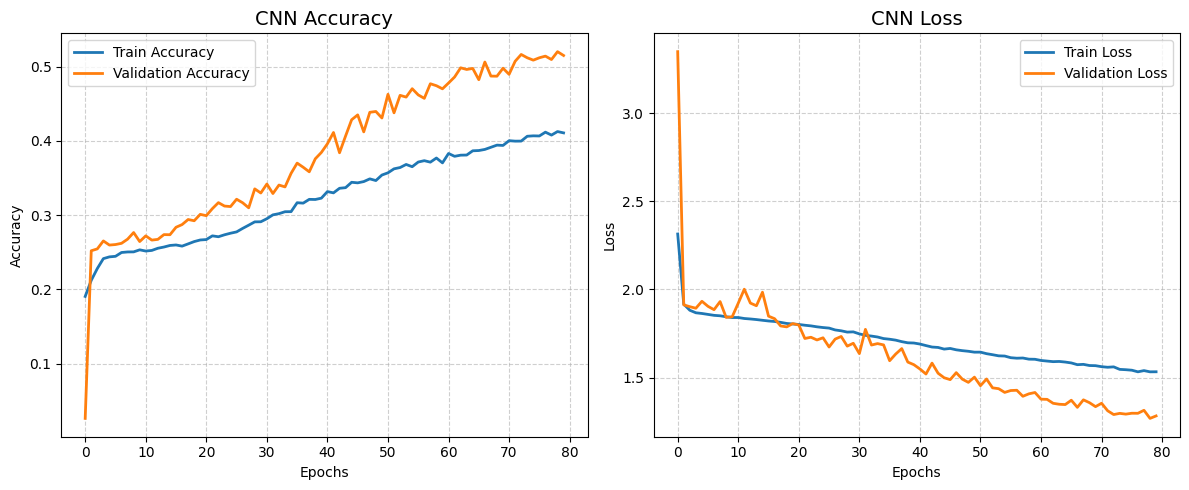

🔄 Merging initial_train and fine_tune histories for VGG16...


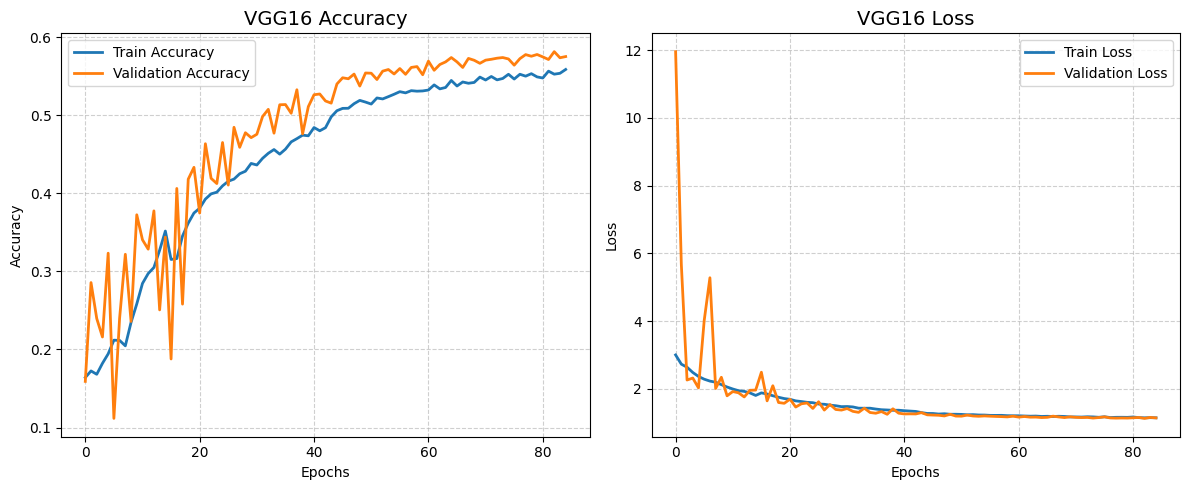

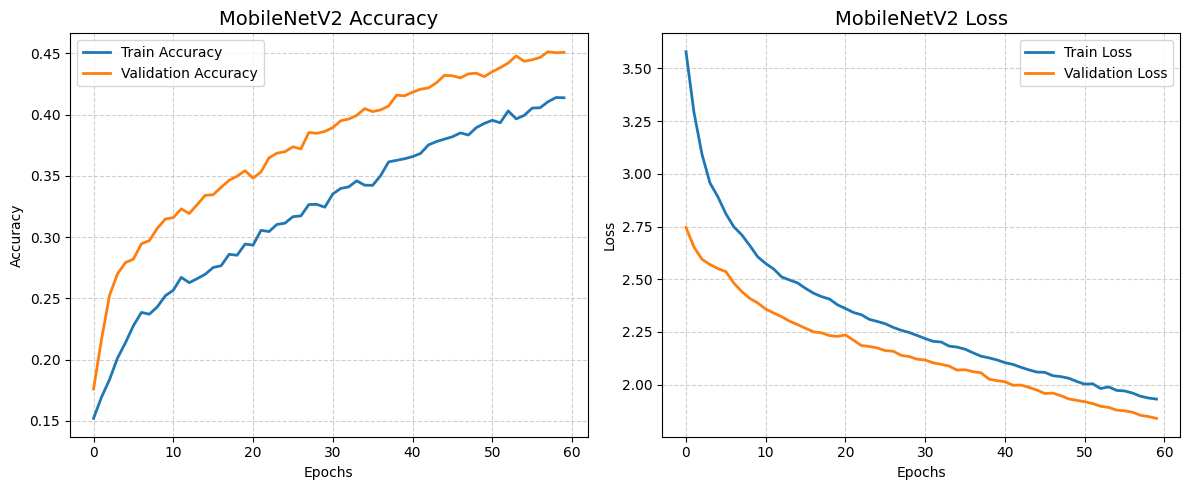

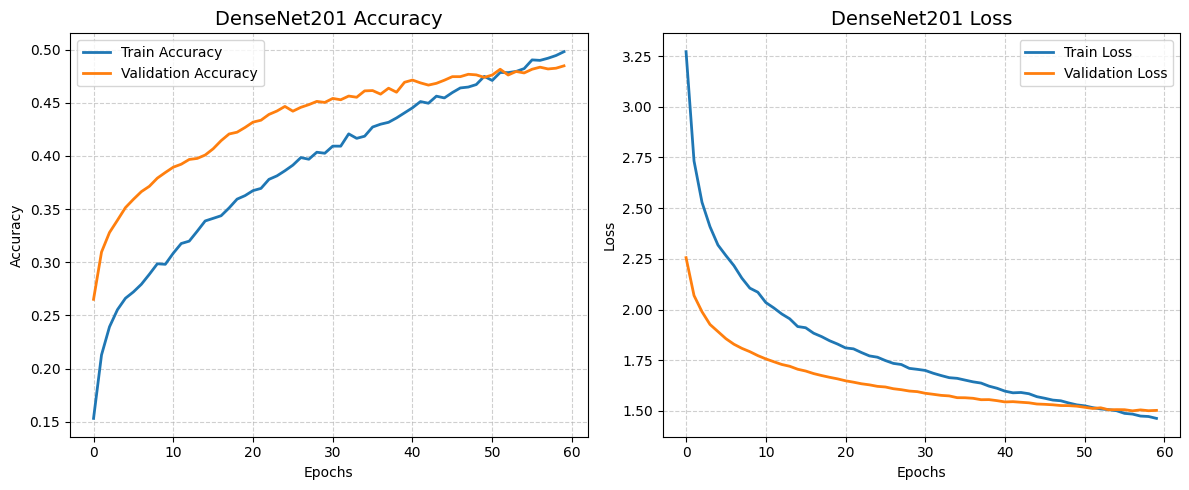

✅ All model accuracy & loss graphs displayed successfully!


In [12]:
from google.colab import drive
import os
import pickle
import matplotlib.pyplot as plt

# ✅ Mount Drive
drive.mount('/content/drive')

# ✅ Path
DRIVE_HISTORY_DIR = "/content/drive/MyDrive/FER_model_histories/"

# ✅ Load function
def load_history(filename):
    path = os.path.join(DRIVE_HISTORY_DIR, filename)
    if os.path.exists(path):
        with open(path, 'rb') as f:
            history = pickle.load(f)
        print(f"✅ Loaded: {filename}")
        return history
    else:
        print(f"⚠️ File not found: {filename}")
        return None

# ✅ Load all model histories
history_cnn = load_history('history_cnn.pkl')
history_vgg = load_history('history_vgg.pkl')
history_mobilenet = load_history('history_mobilenet.pkl')
history_densenet = load_history('history_densenet.pkl')

# ✅ Helper to find correct key
def find_key(history, possible_keys):
    for k in possible_keys:
        if k in history:
            return k
    return None

# ✅ Merge sub-histories (for VGG16)
def merge_histories(sub_histories):
    merged = {}
    for key in sub_histories[0].keys():
        merged[key] = sub_histories[0][key] + sub_histories[1][key]
    return merged

# ✅ Plot function
def plot_model_history(history, model_name):
    if history is None:
        print(f"❌ {model_name} history missing, skipping...\n")
        return

    # Special case for VGG16 (has nested dicts)
    if model_name == "VGG16" and 'initial_train' in history and 'fine_tune' in history:
        print("🔄 Merging initial_train and fine_tune histories for VGG16...")
        history = merge_histories([history['initial_train'], history['fine_tune']])

    acc_key = find_key(history, ['accuracy', 'acc', 'categorical_accuracy'])
    val_acc_key = find_key(history, ['val_accuracy', 'val_acc', 'val_categorical_accuracy'])

    if acc_key is None or val_acc_key is None:
        print(f"⚠️ {model_name}: Accuracy keys not found! Available keys: {list(history.keys())}\n")
        return

    plt.figure(figsize=(12,5))

    # Accuracy Plot
    plt.subplot(1,2,1)
    plt.plot(history[acc_key], label='Train Accuracy', linewidth=2)
    plt.plot(history[val_acc_key], label='Validation Accuracy', linewidth=2)
    plt.title(f"{model_name} Accuracy", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Loss Plot
    plt.subplot(1,2,2)
    plt.plot(history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title(f"{model_name} Loss", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# ✅ Plot all
plot_model_history(history_cnn, "CNN")
plot_model_history(history_vgg, "VGG16")
plot_model_history(history_mobilenet, "MobileNetV2")
plot_model_history(history_densenet, "DenseNet201")

print("✅ All model accuracy & loss graphs displayed successfully!")


✅ RNN history loaded successfully!


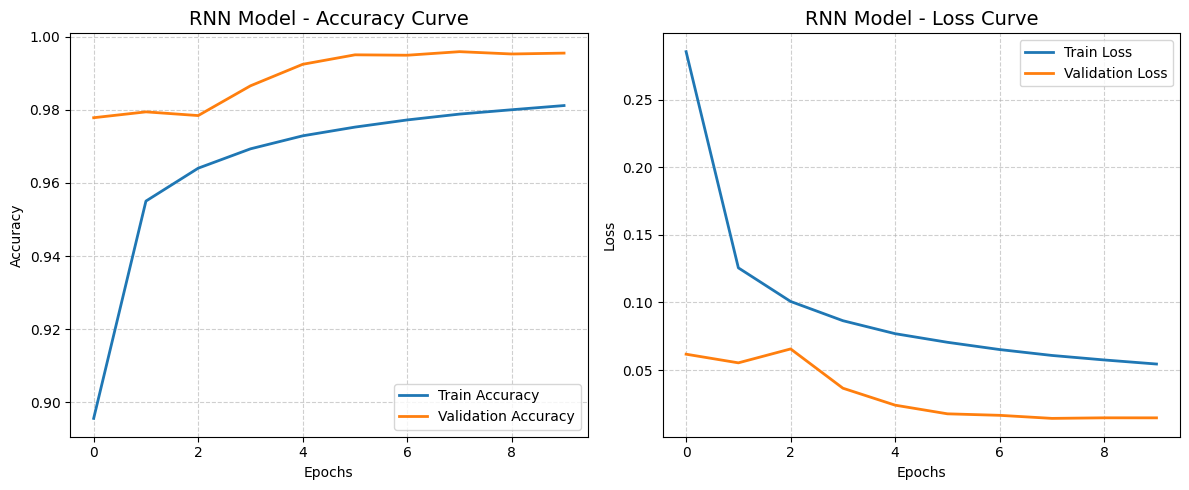

✅ RNN training graphs displayed successfully!


In [13]:
import os
import pickle
import matplotlib.pyplot as plt

# ✅ Path  RNN history
DRIVE_HISTORY_DIR = "/content/drive/MyDrive/RNN_model_histories/"

# ✅ Load RNN history
history_path = os.path.join(DRIVE_HISTORY_DIR, 'history_rnn.pkl')

if os.path.exists(history_path):
    with open(history_path, 'rb') as f:
        history_rnn = pickle.load(f)
    print("✅ RNN history loaded successfully!")
else:
    print("⚠️ history_rnn.pkl not found at:", history_path)
    history_rnn = None

# ✅ Plot if loaded successfully
if history_rnn:
    plt.figure(figsize=(12, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history_rnn['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(history_rnn['val_accuracy'], label='Validation Accuracy', linewidth=2)
    plt.title("RNN Model - Accuracy Curve", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history_rnn['loss'], label='Train Loss', linewidth=2)
    plt.plot(history_rnn['val_loss'], label='Validation Loss', linewidth=2)
    plt.title("RNN Model - Loss Curve", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
    print("✅ RNN training graphs displayed successfully!")


         Model  Validation Accuracy
0          CNN             0.520201
1        VGG16             0.581220
2    MobileNet             0.451489
3  DenseNet201             0.484675


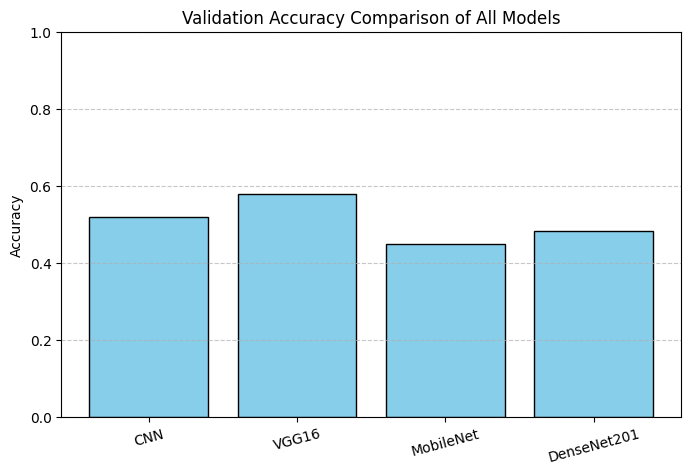

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def get_val_acc(history):
    """Safely fetch val_accuracy (or val_acc) if available."""

    # ✅ Special handling for VGG16 nested history
    if isinstance(history, dict) and 'initial_train' in history and 'fine_tune' in history:
        val_acc_list = []
        for phase in history.values():  # initial_train + fine_tune
            if 'val_accuracy' in phase:
                val_acc_list += phase['val_accuracy']
            elif 'val_acc' in phase:
                val_acc_list += phase['val_acc']
        if val_acc_list:
            return max(val_acc_list)
        else:
            print("⚠️ Validation accuracy key not found in nested history!")
            return None

    # ✅ Normal history handling
    if 'val_accuracy' in history:
        return max(history['val_accuracy'])
    elif 'val_acc' in history:
        return max(history['val_acc'])
    else:
        print("⚠️ Validation accuracy key not found in history!")
        return None

# ✅ Collect validation accuracies
acc_cnn = get_val_acc(history_cnn)
acc_vgg = get_val_acc(history_vgg)          # nested handled here
acc_mobilenet = get_val_acc(history_mobilenet)
acc_densenet = get_val_acc(history_densenet)

# ✅ Create DataFrame for comparison
results = pd.DataFrame({
    'Model': ['CNN', 'VGG16', 'MobileNet', 'DenseNet201'],
    'Validation Accuracy': [acc_cnn, acc_vgg, acc_mobilenet, acc_densenet]
})

# ✅ Display table
print(results)

# ✅ Plot comparison
plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['Validation Accuracy'], color='skyblue', edgecolor='black')
plt.title('Validation Accuracy Comparison of All Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


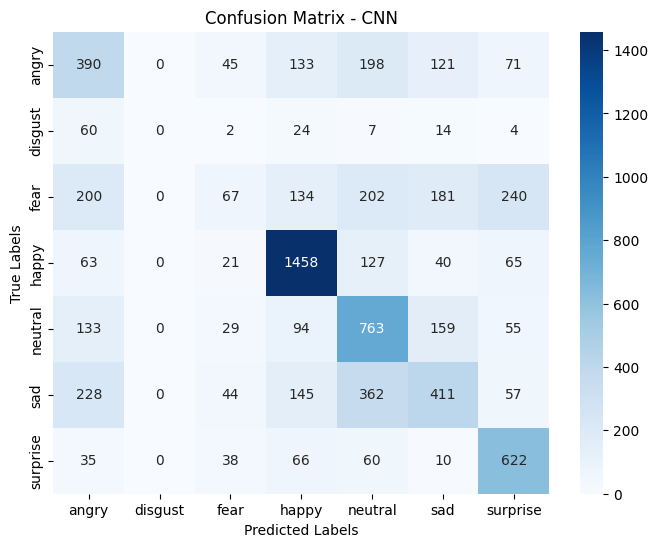


Classification Report:

              precision    recall  f1-score   support

       angry       0.35      0.41      0.38       958
     disgust       0.00      0.00      0.00       111
        fear       0.27      0.07      0.11      1024
       happy       0.71      0.82      0.76      1774
     neutral       0.44      0.62      0.52      1233
         sad       0.44      0.33      0.38      1247
    surprise       0.56      0.75      0.64       831

    accuracy                           0.52      7178
   macro avg       0.40      0.43      0.40      7178
weighted avg       0.48      0.52      0.48      7178



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from tensorflow.keras.models import load_model
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Load trained CNN model from Drive (or local path)
cnn_model = load_model('/content/drive/MyDrive/cnn_gray_models/cnn_balanced_model.h5')

# Step 1: Reset validation generator
val_generator.reset()

# Step 2: True labels
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Step 3: Predict with the loaded CNN model
Y_pred = cnn_model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Step 4: Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Step 5: Visualize
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - CNN')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Step 6: Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


Found 7178 images belonging to 7 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


113/113 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step


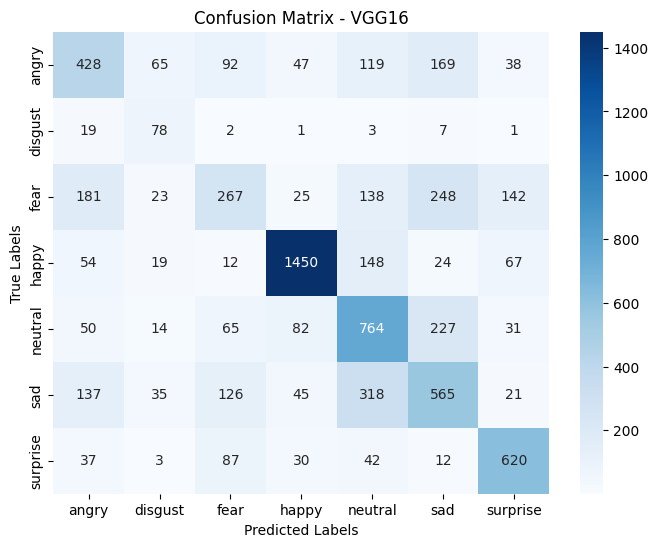


Classification Report:

              precision    recall  f1-score   support

       angry       0.47      0.45      0.46       958
     disgust       0.33      0.70      0.45       111
        fear       0.41      0.26      0.32      1024
       happy       0.86      0.82      0.84      1774
     neutral       0.50      0.62      0.55      1233
         sad       0.45      0.45      0.45      1247
    surprise       0.67      0.75      0.71       831

    accuracy                           0.58      7178
   macro avg       0.53      0.58      0.54      7178
weighted avg       0.58      0.58      0.58      7178



In [36]:
# --- ✅ Imports ---
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- ✅ Paths ---
FER_TEST = '/content/Emotion-Project/Emotion-Project/facial_detection_dataset/test'
MODEL_PATH = "/content/drive/MyDrive/vgg16_gray_finetuned_models/vgg16_gray_balanced_final.keras"
  # Path to your trained VGG16 model

# --- ✅ Check if paths exist ---
if not os.path.exists(FER_TEST):
    raise FileNotFoundError(f"Test folder not found: {FER_TEST}")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

# --- ✅ Load trained VGG16 model ---
vgg_model = load_model(MODEL_PATH)

# --- ✅ Validation Data Generator ---
val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    FER_TEST, target_size=(48,48), color_mode='grayscale',
    class_mode='categorical', batch_size=64, shuffle=False
)

# --- ✅ Get true labels ---
val_generator.reset()
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# --- ✅ Predict ---
Y_pred = vgg_model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

# --- ✅ Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - VGG16')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# --- ✅ Classification Report ---
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


113/113 ━━━━━━━━━━━━━━━━━━━━ 23s 186ms/step


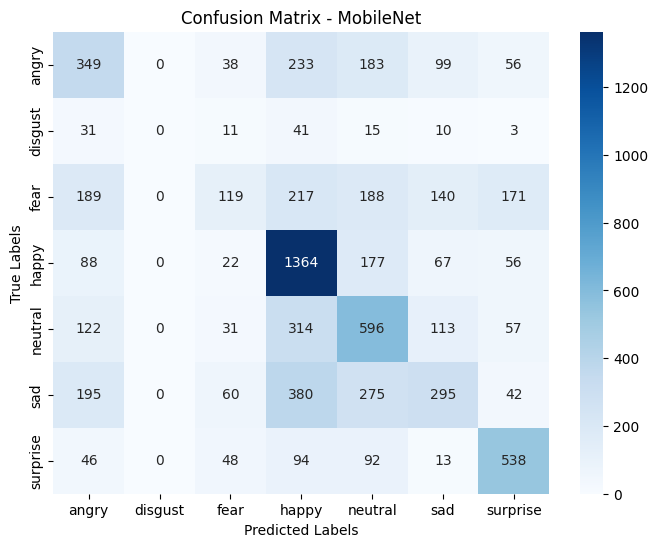


Classification Report:

              precision    recall  f1-score   support

       angry       0.34      0.36      0.35       958
     disgust       0.00      0.00      0.00       111
        fear       0.36      0.12      0.18      1024
       happy       0.52      0.77      0.62      1774
     neutral       0.39      0.48      0.43      1233
         sad       0.40      0.24      0.30      1247
    surprise       0.58      0.65      0.61       831

    accuracy                           0.45      7178
   macro avg       0.37      0.37      0.36      7178
weighted avg       0.43      0.45      0.42      7178



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:
# --- ✅ Imports ---
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- ✅ Paths ---
FER_TEST = '/content/Emotion-Project/Emotion-Project/facial_detection_dataset/test'  # extracted test folder
MODEL_PATH = '/content/drive/MyDrive/mobilenet_gray_models/mobilenet_gray_imagenet_final.h5'             # MobileNet trained model in Drive

# --- ✅ Check if paths exist ---
if not os.path.exists(FER_TEST):
    raise FileNotFoundError(f"Test folder not found: {FER_TEST}")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

# --- ✅ Load trained MobileNet model ---
mobilenet_model = load_model(MODEL_PATH)

# --- ✅ Get true labels ---
val_generator.reset()
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# --- ✅ Predict ---
Y_pred = mobilenet_model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)  # Convert one-hot to class index

# --- ✅ Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - MobileNet')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# --- ✅ Classification Report ---
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


Found 7178 images belonging to 7 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


225/225 ━━━━━━━━━━━━━━━━━━━━ 161s 622ms/step


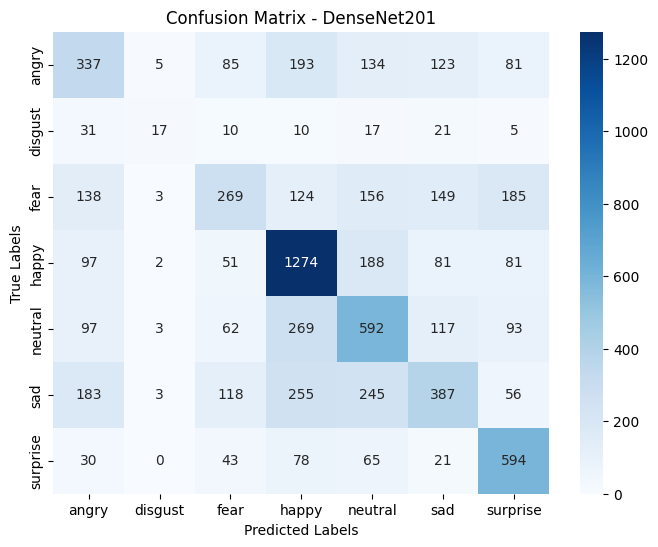


Classification Report:

              precision    recall  f1-score   support

       angry       0.37      0.35      0.36       958
     disgust       0.52      0.15      0.24       111
        fear       0.42      0.26      0.32      1024
       happy       0.58      0.72      0.64      1774
     neutral       0.42      0.48      0.45      1233
         sad       0.43      0.31      0.36      1247
    surprise       0.54      0.71      0.62       831

    accuracy                           0.48      7178
   macro avg       0.47      0.43      0.43      7178
weighted avg       0.47      0.48      0.47      7178



In [43]:
# --- ✅ Imports ---
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

# --- ✅ Paths ---
FER_TEST = '/content/Emotion-Project/Emotion-Project/facial_detection_dataset/test'  # extracted test folder
MODEL_PATH = '/content/drive/MyDrive/densenet201_models/densenet201_emotion_final.keras'  # DenseNet201 trained model in Drive

# --- ✅ Check if paths exist ---
if not os.path.exists(FER_TEST):
    raise FileNotFoundError(f"Test folder not found: {FER_TEST}")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

# --- ✅ Load trained DenseNet201 model ---
densenet_model = load_model(MODEL_PATH)

# --- ✅ Validation Data Generator ---
val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    FER_TEST, target_size=(48,48), color_mode='grayscale',
    class_mode='categorical', batch_size=32, shuffle=False
)

# --- ✅ Get true labels ---
val_generator.reset()
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# --- ✅ Predict ---
Y_pred = densenet_model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)  # Convert one-hot to class index

# --- ✅ Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - DenseNet201')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# --- ✅ Classification Report ---
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


In [48]:
print(os.listdir(FER_TEST + '/happy'))


['PublicTest_72269762.jpg', 'PublicTest_45517414.jpg', 'PublicTest_45859307.jpg', 'PrivateTest_2764941.jpg', 'PrivateTest_74364378.jpg', 'PrivateTest_21388598.jpg', 'PublicTest_79481503.jpg', 'PublicTest_36823992.jpg', 'PrivateTest_10513598.jpg', 'PublicTest_89359277.jpg', 'PublicTest_93745195.jpg', 'PublicTest_95963284.jpg', 'PublicTest_75875276.jpg', 'PrivateTest_91067995.jpg', 'PublicTest_808777.jpg', 'PublicTest_93971981.jpg', 'PublicTest_62157531.jpg', 'PrivateTest_1140198.jpg', 'PrivateTest_10077120.jpg', 'PrivateTest_70553471.jpg', 'PrivateTest_43384411.jpg', 'PublicTest_95830682.jpg', 'PublicTest_1278010.jpg', 'PublicTest_76492533.jpg', 'PrivateTest_29716850.jpg', 'PublicTest_59955381.jpg', 'PrivateTest_68708045.jpg', 'PublicTest_78110412.jpg', 'PublicTest_8979920.jpg', 'PublicTest_49497886.jpg', 'PrivateTest_82652549.jpg', 'PrivateTest_48951404.jpg', 'PrivateTest_94020734.jpg', 'PublicTest_82051328.jpg', 'PrivateTest_6303752.jpg', 'PublicTest_75188569.jpg', 'PrivateTest_563367

In [51]:
import os
os.listdir("/content/drive/MyDrive/Music_Emotion_Project/")


['Final_Music_Emotion_Data.csv']

## Cell 9: Emotion prediction and recommendation function (demo)

In [ ]:
import os
import random
import cv2
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from google.colab import drive

# ================= 1️⃣ Mount Google Drive =================
drive.mount('/content/drive')

# ================= 2️⃣ Load merged dataset =================
MERGED_CSV = "/content/drive/MyDrive/Music_Emotion_Project/Final_Music_Emotion_Data.csv"
merged_df = pd.read_csv(MERGED_CSV)

# ================= 3️⃣ Load VGG16 gray fine-tuned model =================
demo_model = load_model('/content/drive/MyDrive/vgg16_gray_finetuned_models/vgg16_gray_balanced_final.keras')

# ================= 4️⃣ Helper functions =================
# Define your emotion label mapping manually
emotion_labels = {0:'angry', 1:'disgust', 2:'fear', 3:'happy', 4:'sad', 5:'surprise', 6:'neutral'}

def predict_emotion_from_image(img_path, model, use_grayscale=True):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError('Could not read image: '+img_path)
    if use_grayscale:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, (48,48)).astype('float32')/255.0
        tensor = np.expand_dims(np.expand_dims(gray,0), -1)  # (1,48,48,1)
    else:
        rgb = cv2.resize(img, (48,48)).astype('float32')/255.0
        tensor = np.expand_dims(rgb,0)
    preds = model.predict(tensor)
    cls = np.argmax(preds)
    return emotion_labels.get(cls,'unknown')

def recommend_songs_for_emotion(emotion, df, top_n=5):
    subset = df[df['emotion_mapped']==emotion]
    if subset.empty:
        return df.sample(top_n)[['artist','name','emotion_mapped']]
    if 'playcount' in subset.columns:
        subset = subset.sort_values('playcount', ascending=False)
    return subset[['artist','name','emotion_mapped']].head(top_n)

# ================= 5️⃣ Pick a random test image =================
FER_TEST = '/content/Emotion-Project/Emotion-Project/facial_detection_dataset/test'
all_images = [os.path.join(root, f) for root, _, files in os.walk(FER_TEST) for f in files if f.endswith('.jpg')]
img_demo = random.choice(all_images)
print(f"✅ Selected test image: {img_demo}")

# ================= 6️⃣ Predict emotion =================
emotion = predict_emotion_from_image(img_demo, demo_model, use_grayscale=True)
print(f"🎭 Predicted emotion: {emotion}")

# ================= 7️⃣ Recommend songs =================
recommendations = recommend_songs_for_emotion(emotion, merged_df, top_n=5)
print("\n🎵 Top song recommendations for this emotion:")
print(recommendations)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Selected test image: /content/Emotion-Project/Emotion-Project/facial_detection_dataset/test/fear/PrivateTest_98493387.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
🎭 Predicted emotion: surprise

🎵 Top song recommendations for this emotion:
                      artist                        name emotion_mapped
6644450               eagles  what do i do with my heart       surprise
3083599       civil twilight        letters from the sky       surprise
9296648          john denver      leaving on a jet plane       surprise
5201621  starland vocal band           afternoon delight       surprise
1351101          evanescence                 my immortal       surprise
